# Train and Validate
* Train a model across the specified training sites and sampling approach
* Validate the model at the excluded site

## Todo
* Pull out probabilities using model.predict_proba(observations_to_predict)

In [2]:
import pathlib
import numpy
import dask.distributed
import pandas
import joblib

module_path = pathlib.Path.cwd().parent / 'scripts'
import sys
if str(module_path) not in sys.path:
    sys.path.append(str(module_path))
import utils
import sentinel2
import training
import sampling

%load_ext autoreload
%autoreload 2

# Values to edit

In [3]:
sample_method = "sampling_2"
method_2_threshold = .97 # .98 .99 .97 .95

In [4]:
# View the amount of training data for the selected sampling apporach
samples_per_site = pandas.read_csv(utils.get_samples_summary_file_path(sample_method, method_2_threshold))
samples_per_site

,Glare,Gracilaria,Gracilaria submerged,Microphytobenthos,Rock,Saltmarsh,Seagrass,Seagrass submerged,Shadow,Submerged vegetation,Terrestrial,Ulva,Ulva mats,Unvegetated,Water
0,0,770,819,0,0,0,0,0,0,0,0,0,0,22991,6038
1,32,0,0,0,4,0,74,0,0,0,626,0,0,2382,272
2,0,0,0,0,0,0,26,0,0,0,0,0,0,524,1188
3,0,0,0,1,0,0,434,173,2,0,0,0,0,637,2561
4,0,1236,0,0,0,246,377,0,0,1632,46,92,721,23854,6532
5,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0
7,0,0,0,0,0,0,0,0,3,1,0,0,0,6,146
8,0,0,0,0,0,0,2,0,0,0,0,0,0,31,51
9,0,0,0,0,0,0,2,0,0,0,0,4,0,1,35


In [5]:
all_training_sites =  ["CatlinsLake", "CatlinsRiverMouth", "Childrens", "Duvauchelle", "Robinsons", "Takamatua", "Purau", "Ihutai",
              "IveyBay_Nov25", "IveyBay_Feb26", "LeftBank_Nov25", "LeftBank_Feb26", "Paremata_Nov25", "Paremata_Feb26",
              "Paremata_Feb25", "ThePoint_Nov25", "ThePoint_Feb26", "Takapuwahia_Nov25", "Takapuwahia_Feb26", "IveyBay_ThePoint_LeftBank_Oct24"]

In [6]:
test_site = "Ihutai"
training_sites = ["Duvauchelle", "Robinsons", "Childrens", "Takamatua"] # all_training_sites.copy()
model_file = utils.get_model_file(f"trained_on_akaroa_sites_threshold_{int(method_2_threshold*100)}_tested_on_{test_site}")

# Ensure not training on test site
if test_site in training_sites:
    training_sites.remove(test_site)


In [7]:
# Mappings of Satellite classes to consider from UAV classes
uav_classes_to_ignore = ['Shadow', 'Glare']
satellite_classes = {'Seagrass': 1, 'Mixed': 2, 'Unvegetated': 3, 'Water': 4,}
satellite_from_uav_classes = {'Seagrass': ['Seagrass', 'Seagrass submerged'],
 'Mixed': ['Gracilaria', 'Ulva', 'Cystophora', 'Hormosira', 'Gracilaria submerged', 'Submerged vegetation',
           'Brown algae mixed', 'Microphytobenthos', 'Green algae mixed', 
           'Filamentous brown algae', 'Ulva mats', 'Terrestrial', 'Red algae mixed'],
  'Unvegetated': ['Saltmarsh', 'Unvegetated', 'Rock', ],
                              
  'Water': ['Water'],
}

# Cells to run
* Train and save model
* Review model
  * satellite bands of each UAV class
  * satellite bands of each satellite class
  * importance of satellite bands in trained model
* Validation
  * Predict excluded site
  * Plot confusion matrix comparing prediction to UAV classifications

In [8]:
cluster = dask.distributed.LocalCluster()
client = dask.distributed.Client(cluster)
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:61050/status,
Dashboard: http://127.0.0.1:61050/status,Workers: 4
Total threads: 8,Total memory: 31.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:61055,Workers: 4
Dashboard: http://127.0.0.1:61050/status,Total threads: 8
Started: Just now,Total memory: 31.73 GiB
Comm: tcp://127.0.0.1:61086,Total threads: 2
Dashboard: http://127.0.0.1:61087/status,Memory: 7.93 GiB
Nanny: tcp://127.0.0.1:61059,


In [9]:
data_path = utils.get_data_path()
utils.create_data_folders()
uav_labels_file = data_path / "ELF24505_ClassificationClasses.txt"
sample_folder = utils.get_samples_path(sample_method=sample_method, method_2_threshold=method_2_threshold)

test_satellite_file = data_path / "training" / "satellite_images" / f"{test_site}_sentinel-2.nc"
test_polygon_file = polygon_file = utils.get_site_polygon_path(test_site)
test_uav_file = data_path / "classified_orthos" / f"{test_site}_classified.tif"

test_prediction_file = data_path / "validation" / "predictions" / f"{test_site}_prediction_{model_file.stem}.nc"

### Train and save model

In [10]:
if not model_file.exists():
    # train and save the model
    model, training_dataframe = training.train_classifier(
        training_sites=training_sites,
        samples_path=sample_folder,
        uav_labels_file=uav_labels_file,
        uav_classes_to_ignore=uav_classes_to_ignore,
        satellite_classes=satellite_classes,
        satellite_from_uav_classes=satellite_from_uav_classes)
    
    # Save model
    joblib.dump(model, model_file); # , compress=3);
    
    # Save a record of the classes considered in training
    satellite_classes_dataframe = pandas.DataFrame.from_dict(satellite_classes, orient='index', columns=['satellite_class_id'])
    satellite_classes_dataframe['uav_class_ids'] = satellite_classes_dataframe.index.map(lambda key: f"{satellite_from_uav_classes[key]}")
    satellite_classes_dataframe.to_csv(model_file.with_name(f"{model_file.stem}_class_mappings.csv"), index=True)
else:
    print(f"Model '{model_file.name}' already exists. Delete if you want to recreate it.")

print("\nSatellite training classes present: "
      f"{[key for key, value in satellite_classes.items() if value in training_dataframe['satellite_class_id'].unique()]}")

	Load in sites: ['Duvauchelle', 'Robinsons', 'Childrens', 'Takamatua']
	Map UAV training ids to the specified satellite training ids
	Train a Random Forest Model

Satellite training classes present: ['Seagrass', 'Mixed', 'Unvegetated', 'Water']


### Review model

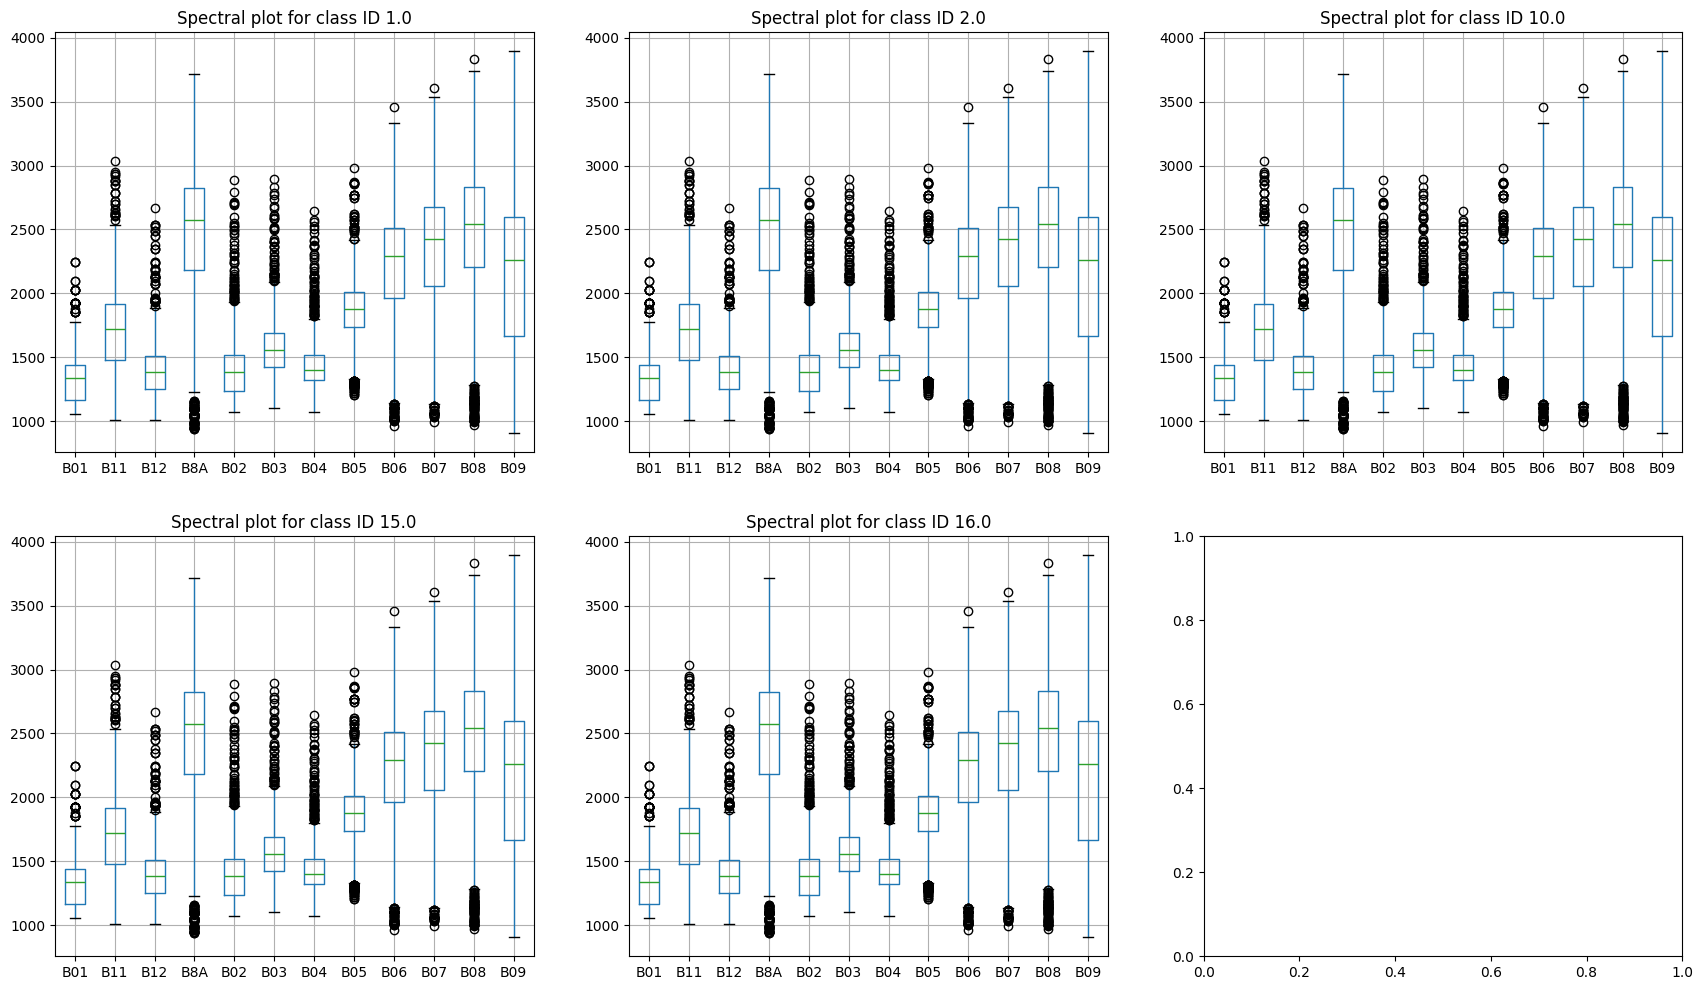

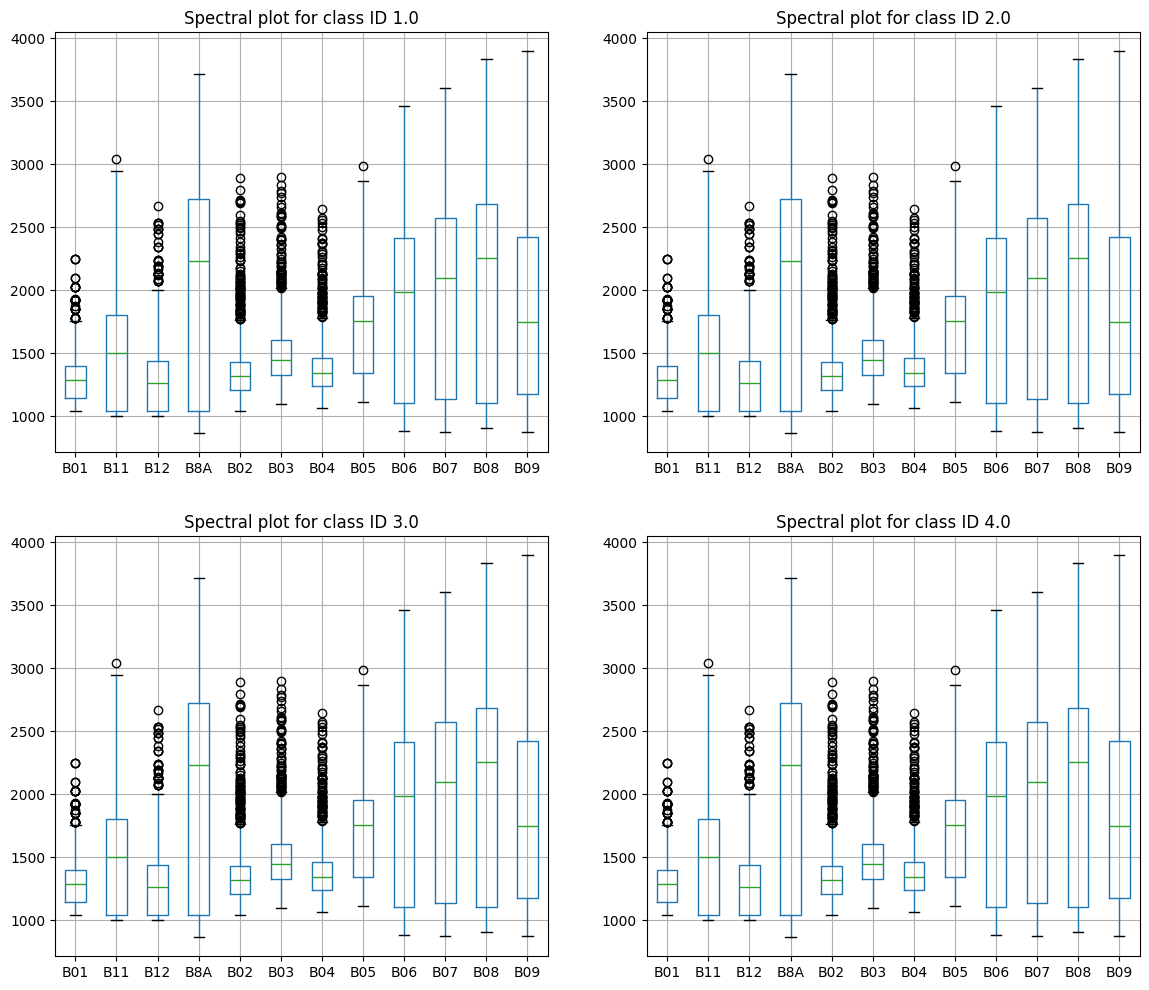

In [11]:
training.plot_training_data_class_distribution(training_dataframe=training_dataframe, model_file=model_file)

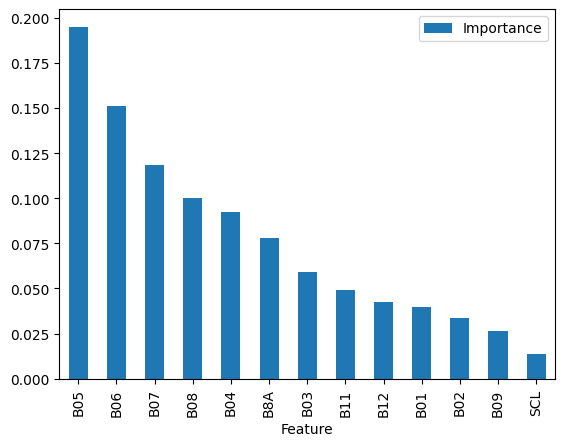

In [12]:
training.plot_model_feature_importance(training_dataframe=training_dataframe, model_file=model_file)

### Validate 

In [13]:
if not test_prediction_file.exists():

    predictions, satellite_data = training.predict_site(test_satellite_file=test_satellite_file, polygon_file=test_polygon_file, model_file=model_file)
    utils.save_netcdf(predictions, test_prediction_file)
else:
    print(f"Prediction file '{test_prediction_file.name}' already eixsts. Delete if you want to repredict.")
    satellite_data = utils.load_satellite(filename=test_satellite_file)
    predictions = utils.load_classification(filename=test_prediction_file, chunks=None)

print(
    f"Satellite training classes present: {[key for key, value in satellite_classes.items() if value in training_dataframe['satellite_class_id'].unique()]}. "
    f"Predicted classes present: {[key for key, value in satellite_classes.items() if value in numpy.unique(predictions.data)]}"
     )

	Predict for 1 satellite images
	Combine predictions and clip to polygon
Satellite training classes present: ['Seagrass', 'Mixed', 'Unvegetated', 'Water']. Predicted classes present: ['Seagrass', 'Unvegetated', 'Water']


	Load images and match resolution to UAV then compare predictions to UAV
	Load UAV image
	Construct confusion matrix for time index: 0
	Overall confusion matrix across prediction dates


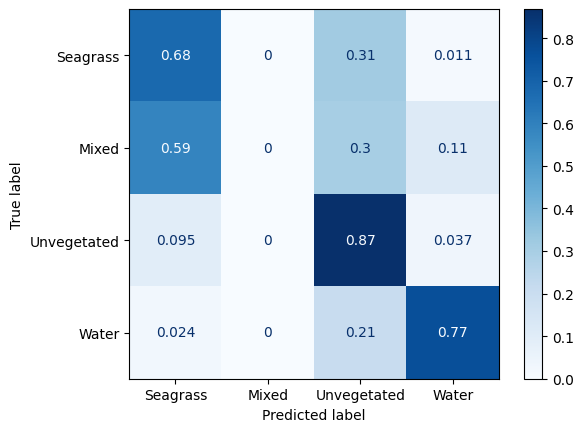

In [14]:
training.confusion_matrix_of_site(
    test_uav_file=test_uav_file,
    uav_labels_file=uav_labels_file,
    prediction_file=test_prediction_file,
    satellite_classes=satellite_classes,
    satellite_from_uav_classes=satellite_from_uav_classes,
    uav_classes_to_ignore=uav_classes_to_ignore,
    polygon_file=test_polygon_file)